In [1]:
import os
#from obspy.core import UTCDateTime
#from obspy.clients.fdsn import Client
from variables import *
from functions.get_data import get_data
from obspy import read
from obspy.signal import konnoohmachismoothing
import numpy as np

In [2]:
get_data()

File data/TO_PE50_20080820_190000.mseed already exists. Skipping download.


In [3]:
files = os.listdir(output_dir)
for file in files:
    print(file)
filename = os.path.join(output_dir,files[0])

TO_PE50_20080820_190000.mseed


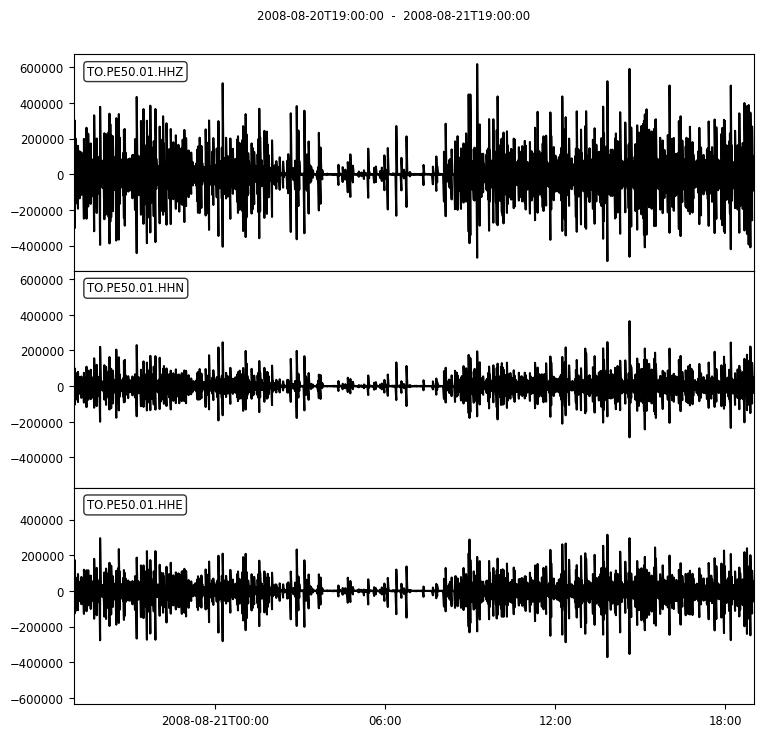

3 Trace(s) in Stream:
TO.PE50.01.HHE | 2008-08-20T19:00:00.000000Z - 2008-08-21T19:00:00.000000Z | 100.0 Hz, 8640001 samples
TO.PE50.01.HHN | 2008-08-20T19:00:00.000000Z - 2008-08-21T19:00:00.000000Z | 100.0 Hz, 8640001 samples
TO.PE50.01.HHZ | 2008-08-20T19:00:00.000000Z - 2008-08-21T19:00:00.000000Z | 100.0 Hz, 8640001 samples

In [4]:
st = read(filename)
_= st.plot()
st.detrend(type = 'demean')
st.detrend(type = 'linear')

In [ ]:
tr = st.copy()
start_time = tr[0].stats.starttime
window_size = 60
total_windows = 24 * 60  

slices = []

for i in range(total_windows):
    slice_start = start_time + (i*window_size)
    slice_end = slice_start + window_size

    tr_slice = tr.slice(starttime = slice_start, endtime = slice_end)
    tr_slice.detrend(type = "demean")
    tr_slice.detrend(type = "linear")
    slices.append(tr_slice)
print(f"Successfully created {len(slices)} half-a-minute-long slices.")

Successfully created 2880 half-a-minute-long slices.


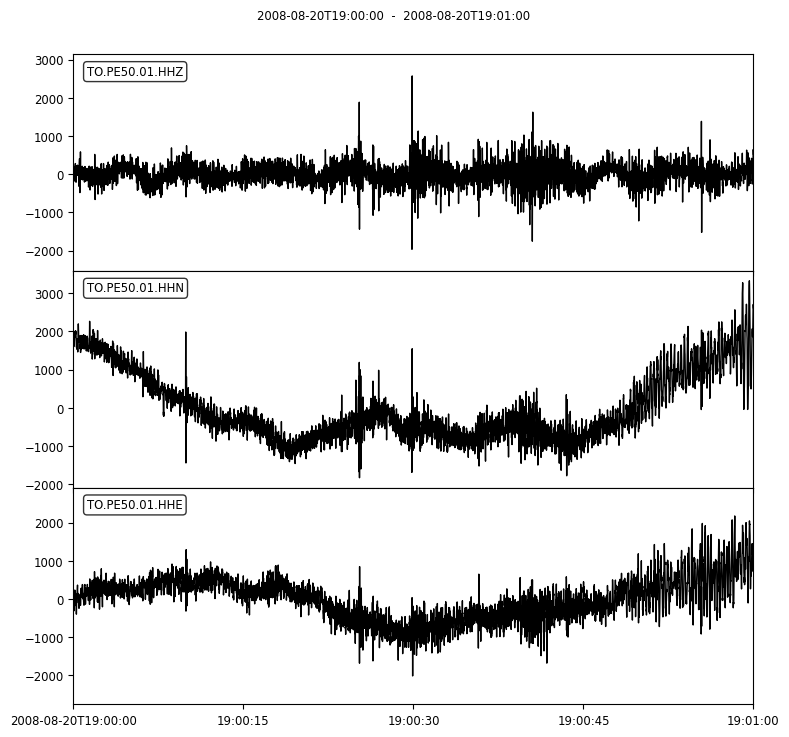

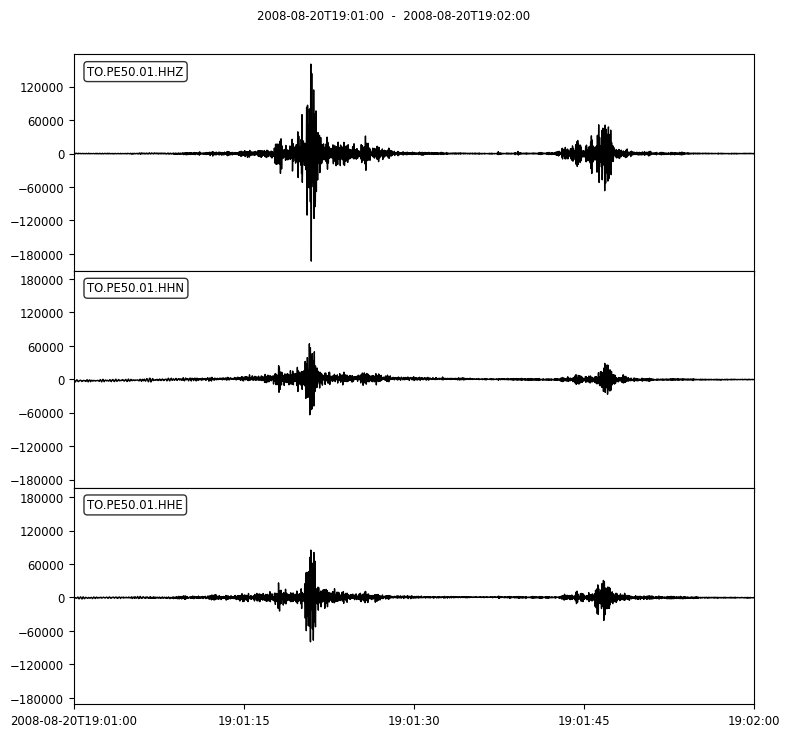

In [6]:
_ =slices[0].plot()
_ =slices[1].plot()

In [23]:
from functions.filtering import sta_lta_window_rejection, reject_low_frequency_windows, filter_stream_by_sta_lta
#from functions.filtering import filter_windows_by_low_freq_power
filter1 = sta_lta_window_rejection(slices)#filter_stream_by_sta_lta(st)

filter2 = reject_low_frequency_windows(filter1, amplitude_ratio_threshold=2)
#filter_google = filter_windows_by_low_freq_power(filter1)
print("After applying filter 1:",len(filter1))
print("After applying filter 2:",len(filter2))

After applying filter 1: 861
After applying filter 2: 189


In [24]:
data = []
pp = filter2.copy()
for window in pp:
    window.filter("bandpass", freqmin = 0.1,freqmax = 20, corners = 4, zerophase = True)
    window.taper(max_percentage=0.05, type="cosine")
    data.append(window)
print(len(data))

189


In [7]:
def nextpow2(n, minimum_power_of_two=2**15):  # 2**15 = 32768
    power_of_two = minimum_power_of_two
    while True:
        if power_of_two > n:
            return power_of_two
        power_of_two *= 2
bwidth = 40
max_n_samples = data[0][-1].stats.npts
good_n = nextpow2(max_n_samples)
dt = data[0][-1].stats.delta
fft_frq = np.fft.rfftfreq(good_n, dt)
smoothMatrix = konnoohmachismoothing.calculate_smoothing_matrix(fft_frq, bandwidth= bwidth, normalize = True)

In [73]:
from numpy.fft import rfft
def total_horizontal_energy(ns, ew, settings=None):
    """Computes the magnitude of sum of two orthoginal vectors."""
    return np.sqrt((ns*ns + ew*ew))
def geomean(ns,ew):
      return np.sqrt(ns*ew)
waveforms = []
for window in data:
        #PROCESING
        #number_of_data_points = 200
        #center_frequencies_in_hz = np.geomspace(
        #                    min_frequency, max_frequency, number_of_data_points)
        fft_ns = np.abs(rfft(window[1].data, good_n))
        fft_ew = np.abs(rfft(window[0].data, good_n))
        h = geomean(fft_ns, fft_ew)
        v = np.abs(rfft(window[2].data, good_n))
        #SMOOTHING
        h_smooth = konnoohmachismoothing.apply_smoothing_matrix(h,smoothMatrix, count = 1)
        v_smooth = konnoohmachismoothing.apply_smoothing_matrix(v, smoothMatrix, count = 1)
        hvsr = h_smooth/v_smooth
        waveforms.append(hvsr)

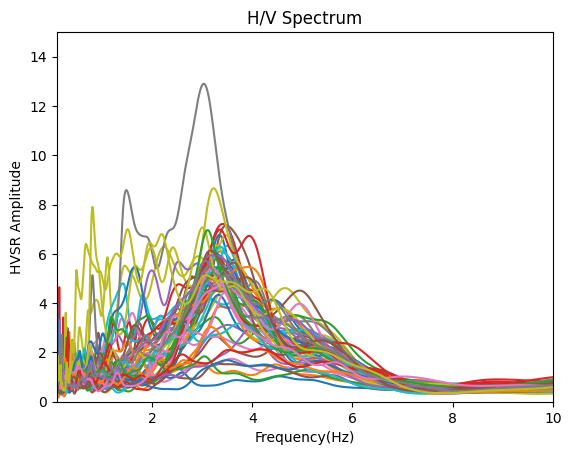

In [75]:
import matplotlib.pyplot as plt

for w in waveforms:
    plt.plot(fft_frq, w)
#plt.xlim(fmin,fmax)
plt.title("H/V Spectrum")
plt.xlabel('Frequency(Hz)')
plt.ylabel("HVSR Amplitude")
plt.xlim(0.1,10)
#plt.xscale('log')
plt.ylim(0,15)
plt.show()

In [76]:
from scipy.signal import find_peaks
mean_curve = np.mean(waveforms, axis = 0)
std_curve = np.std(waveforms, axis=0)

peak_indices, properties = find_peaks(mean_curve, distance=20)

if len(peak_indices) == 0:
    # Fallback if no distinct peak is found: take the absolute maximum
    max_idx = np.argmax(mean_curve)
else:
    # Find which of the local peaks is the absolute tallest
    max_idx = peak_indices[np.argmax(mean_curve[peak_indices])]

peak_freq = fft_frq[max_idx]
peak_amplitude = mean_curve[max_idx]

peak_error_amplitude = std_curve[max_idx] 
individual_peak_freqs = []

for curve in waveforms:
    ind_max_idx = np.argmax(curve)
    individual_peak_freqs.append(fft_frq[ind_max_idx])

freq_error = np.std(individual_peak_freqs)

# --- 5. PRINT RESULTS ---
print(f"--- Peak Estimation Results ---")
print(f"Dominant Peak Frequency : {peak_freq:.3f} Hz ± {freq_error:.3f} Hz")
print(f"Peak Amplitude (Value)  : {peak_amplitude:.3f} ± {peak_error_amplitude:.3f}")

--- Peak Estimation Results ---
Dominant Peak Frequency : 3.329 Hz ± 1.492 Hz
Peak Amplitude (Value)  : 4.660 ± 1.774


In [ ]:
from obspy import Stream
from obspy.signal.trigger import classic_sta_lta

def slice_and_reject(stream,
                     window_seconds=60,
                     sta_seconds=1,
                     lta_seconds=20,
                     min_ratio=0.01,
                     max_ratio=5,
                     components=["E", "N", "Z"]):
    """
    Slice a long stream into fixed windows and keep only
    those that pass the STA/LTA threshold on all components.

    Returns a list of obspy Stream objects (one per valid window).
    """
    passing_windows = []

    # Use one reference trace to build the time grid
    ref_trace = stream[0]
    dt = ref_trace.stats.delta
    starttime = ref_trace.stats.starttime
    endtime = ref_trace.stats.endtime

    npts_sta = int(sta_seconds / dt)
    npts_lta = int(lta_seconds / dt)
    npts_window = int(window_seconds / dt)

    # Sanity check
    if npts_lta >= npts_window:
        raise ValueError(
            f"lta_seconds ({lta_seconds}s) must be shorter than "
            f"window_seconds ({window_seconds}s)."
        )

    # Build window start times
    t = starttime
    while t + window_seconds <= endtime:
        window_stream = stream.slice(t, t + window_seconds)
        window_is_valid = True

        for component in components:
            matching = window_stream.select(component=component)
            if not matching:
                continue  # or set window_is_valid = False if component is mandatory

            trace = matching[0]

            # Skip windows with unexpected length (gaps, incomplete data)
            if trace.stats.npts < npts_window:
                window_is_valid = False
                break

            cft = classic_sta_lta(trace.data, npts_sta, npts_lta)
            cft_valid = cft[npts_lta:]   # skip warm-up zone

            if cft_valid.max() > max_ratio or cft_valid.min() < min_ratio:
                window_is_valid = False
                break

        if window_is_valid:
            passing_windows.append(window_stream)

        t += window_seconds   # advance by one full window (no overlap)
        # for 50% overlap use: t += window_seconds / 2

    print(f"Kept {len(passing_windows)} / {int((endtime - starttime) / window_seconds)} windows")
    return passing_windows
filtered = slice_and_reject(st)

Kept 257 / 1440 windows


59
59


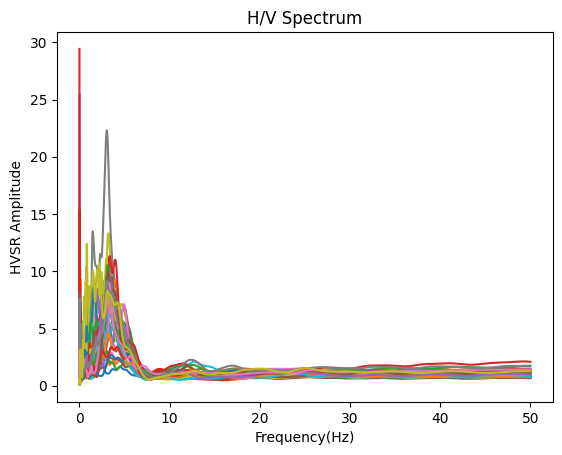

In [42]:
filtered2 = reject_low_frequency_windows(filtered, amplitude_ratio_threshold=2)
print(len(filtered2))
data = []
pp = filtered2.copy()
for window in pp:
    window.filter("bandpass", freqmin = 0.1,freqmax = 20, corners = 4, zerophase = True)
    window.taper(max_percentage=0.05, type="cosine")
    data.append(window)
print(len(data))
waveforms = []
for window in data:
        #PROCESING
        #number_of_data_points = 200
        #center_frequencies_in_hz = np.geomspace(
        #                    min_frequency, max_frequency, number_of_data_points)
        fft_ns = np.abs(rfft(window[1].data, good_n))
        fft_ew = np.abs(rfft(window[0].data, good_n))
        h = total_horizontal_energy(fft_ns, fft_ew)
        v = np.abs(rfft(window[2].data, good_n))
        #SMOOTHING
        h_smooth = konnoohmachismoothing.apply_smoothing_matrix(h,smoothMatrix, count = 1)
        v_smooth = konnoohmachismoothing.apply_smoothing_matrix(v, smoothMatrix, count = 1)
        hvsr = h_smooth/v_smooth
        waveforms.append(hvsr)


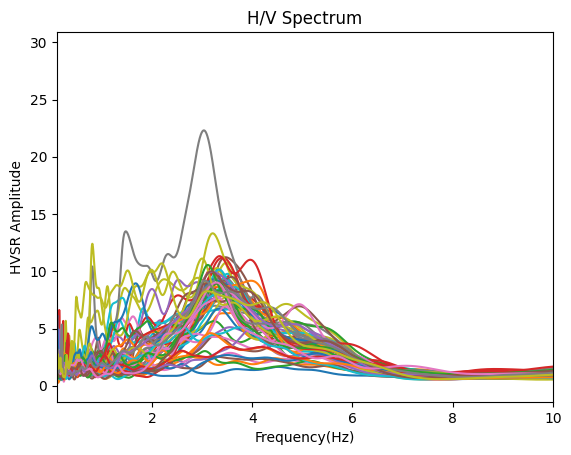

In [47]:
for w in waveforms:
    plt.plot(fft_frq, w)
#plt.xlim(fmin,fmax)
plt.title("H/V Spectrum")
plt.xlabel('Frequency(Hz)')
plt.ylabel("HVSR Amplitude")
plt.xlim(0.1,10)#plt.xscale('log')
#plt.ylim(0,30)
plt.show()

In [65]:
def iterative_hvsr_rejection(hvsr_curves, frequencies, n=2, max_iterations=50,
                             f_min=0.5, f_max=20.0):
    hvsr_curves = np.asarray(hvsr_curves)

    # --- Pre-filter: restrict frequency search range ---
    freq_mask = (frequencies >= f_min) & (frequencies <= f_max)
    if not np.any(freq_mask):
        raise ValueError(f"No frequencies found between {f_min} and {f_max} Hz.")

    masked_freqs = frequencies[freq_mask]

    # Pre-filter windows: keep only those whose peak falls inside [f_min, f_max]
    masked_curves_all = hvsr_curves[:, freq_mask]
    peak_indices_all  = np.argmax(masked_curves_all, axis=1)
    f0_all            = masked_freqs[peak_indices_all]

    valid_start = (f0_all >= f_min) & (f0_all <= f_max)
    print(f"Pre-filter: {valid_start.sum()} / {len(hvsr_curves)} windows have f0 in [{f_min}, {f_max}] Hz")

    active_indices = valid_start.copy()

    for iteration in range(max_iterations):
        current_curves  = masked_curves_all[active_indices]  # use masked freqs only
        if len(current_curves) == 0:
            raise ValueError("All windows were rejected.")

        # --- BOX 1 ---
        peak_indices_b = np.argmax(current_curves, axis=1)
        f0_array_b     = masked_freqs[peak_indices_b]
        ln_f0_b        = np.log(f0_array_b)   # safe: f0 >= f_min > 0

        mu_b    = np.mean(ln_f0_b)
        sigma_b = np.std(ln_f0_b)
        LM_b    = np.exp(mu_b)

        median_curve_b = np.median(current_curves, axis=0)
        f0_mc_b        = masked_freqs[np.argmax(median_curve_b)]
        d_b            = np.abs(LM_b - f0_mc_b)

        # --- BOX 2 ---
        lower_bound = np.exp(mu_b - n * sigma_b)
        upper_bound = np.exp(mu_b + n * sigma_b)

        current_active_idx  = np.where(active_indices)[0]
        new_active_indices  = np.zeros(hvsr_curves.shape[0], dtype=bool)

        for idx, f0_i in zip(current_active_idx, f0_array_b):
            if lower_bound <= f0_i <= upper_bound:
                new_active_indices[idx] = True

        # --- BOX 3 ---
        passed_curves = masked_curves_all[new_active_indices]
        if len(passed_curves) == 0:
            raise ValueError("All windows rejected during iteration.")

        peak_indices_e = np.argmax(passed_curves, axis=1)
        f0_array_e     = masked_freqs[peak_indices_e]
        ln_f0_e        = np.log(f0_array_e)

        mu_e    = np.mean(ln_f0_e)
        sigma_e = np.std(ln_f0_e)
        LM_e    = np.exp(mu_e)

        median_curve_e = np.median(passed_curves, axis=0)
        f0_mc_e        = masked_freqs[np.argmax(median_curve_e)]
        d_e            = np.abs(LM_e - f0_mc_e)

        # --- BOX 4 ---
        if d_b == 0:
            cond_d = (d_e == 0)
        else:
            cond_d = (np.abs(d_e - d_b) / d_b) < 0.01

        cond_sigma = np.abs(sigma_e - sigma_b) < 0.01

        active_indices = new_active_indices

        print(f"Iter {iteration+1}: kept {active_indices.sum()} windows | "
              f"f0 bounds [{lower_bound:.3f}, {upper_bound:.3f}] Hz | "
              f"sigma: {sigma_b:.4f}→{sigma_e:.4f} | "
              f"d: {d_b:.4f}→{d_e:.4f}")

        if cond_d and cond_sigma:
            print(f"Converged at iteration {iteration+1}.")
            break

    # Return original full-spectrum curves (not frequency-masked) for the accepted windows
    return hvsr_curves[active_indices]

Pre-filter: 59 / 59 windows have f0 in [0.5, 20.0] Hz
Iter 1: kept 55 windows | f0 bounds [1.240, 6.924] Hz | sigma: 0.4299→0.1609 | d: 0.5394→0.2001
Iter 2: kept 53 windows | f0 bounds [2.364, 4.498] Hz | sigma: 0.1609→0.0844 | d: 0.2001→0.0935
Iter 3: kept 49 windows | f0 bounds [2.829, 3.964] Hz | sigma: 0.0844→0.0620 | d: 0.0935→0.0611
Iter 4: kept 47 windows | f0 bounds [2.963, 3.797] Hz | sigma: 0.0620→0.0538 | d: 0.0611→0.0603
Iter 5: kept 43 windows | f0 bounds [3.012, 3.736] Hz | sigma: 0.0538→0.0447 | d: 0.0603→0.0016
Iter 6: kept 41 windows | f0 bounds [3.052, 3.649] Hz | sigma: 0.0447→0.0407 | d: 0.0016→0.0020
Iter 7: kept 39 windows | f0 bounds [3.076, 3.621] Hz | sigma: 0.0407→0.0371 | d: 0.0020→0.0055
Iter 8: kept 38 windows | f0 bounds [3.099, 3.595] Hz | sigma: 0.0371→0.0352 | d: 0.0055→0.0015
Iter 9: kept 37 windows | f0 bounds [3.105, 3.574] Hz | sigma: 0.0352→0.0335 | d: 0.0015→0.0051
Iter 10: kept 37 windows | f0 bounds [3.109, 3.555] Hz | sigma: 0.0335→0.0335 | d:

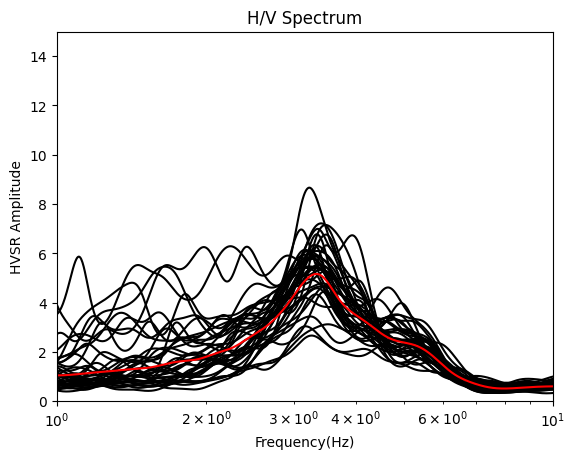

In [77]:

clean_hvsr_curves = iterative_hvsr_rejection(waveforms,fft_frq, n = 2)
print(len(waveforms), len(clean_hvsr_curves))
final_hvsr_log_mean = np.mean(np.log(clean_hvsr_curves), axis=0)
final_hvsr_curve = np.exp(final_hvsr_log_mean)
for c in clean_hvsr_curves:
    plt.plot(fft_frq, c, color = 'k')
#plt.xlim(fmin,fmax)
plt.plot(fft_frq,final_hvsr_curve, color = 'r')
plt.title("H/V Spectrum")
plt.xlabel('Frequency(Hz)')
plt.ylabel("HVSR Amplitude")
plt.xlim(1,10)
plt.xscale('log')
plt.ylim(0,15)
plt.show()


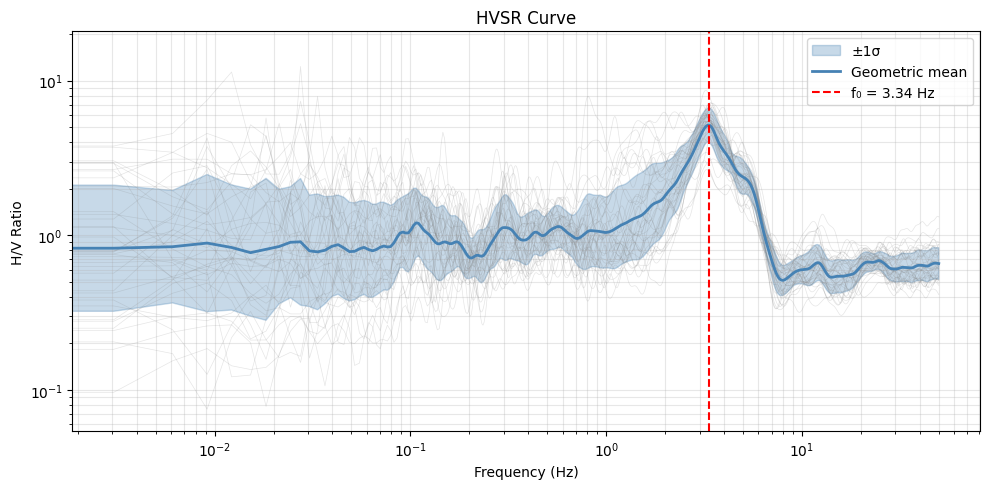

In [78]:
def compute_hvsr_mean_and_bounds(hvsr_curves):
    """
    Compute the geometric mean HVSR curve and ±1 lognormal sigma bounds.

    Parameters
    ----------
    hvsr_curves : np.ndarray
        Shape (n_windows, n_frequencies). Must be the accepted windows only.

    Returns
    -------
    mean_curve  : np.ndarray  shape (n_frequencies,)
    upper_bound : np.ndarray  shape (n_frequencies,)
    lower_bound : np.ndarray  shape (n_frequencies,)
    sigma       : np.ndarray  shape (n_frequencies,)
    """
    hvsr_curves = np.asarray(hvsr_curves)

    ln_curves = np.log(hvsr_curves)          # log of each window, each freq bin

    mu_ln    = np.mean(ln_curves, axis=0)    # shape (n_frequencies,)
    sigma_ln = np.std(ln_curves,  axis=0)    # shape (n_frequencies,)

    mean_curve  = np.exp(mu_ln)
    upper_bound = np.exp(mu_ln + sigma_ln)
    lower_bound = np.exp(mu_ln - sigma_ln)

    return mean_curve, upper_bound, lower_bound, sigma_ln

mean_curve, upper_bound, lower_bound, sigma = compute_hvsr_mean_and_bounds(clean_hvsr_curves)

fig, ax = plt.subplots(figsize=(10, 5))

# Individual windows (light, in background)
for curve in clean_hvsr_curves:
    ax.plot(fft_frq, curve, color="gray", alpha=0.2, linewidth=0.5)

# ±1σ shaded band
ax.fill_between(fft_frq, lower_bound, upper_bound,
                alpha=0.3, color="steelblue", label="±1σ")

# Mean curve
ax.plot(fft_frq, mean_curve, color="steelblue",
        linewidth=2, label="Geometric mean")

# f0 line
f0 = fft_frq[np.argmax(mean_curve)]
ax.axvline(f0, color="red", linestyle="--", label=f"f₀ = {f0:.2f} Hz")

ax.set_xscale("log")
ax.set_yscale("log")           # log-log makes the sigma bands look symmetric
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("H/V Ratio")
ax.set_title("HVSR Curve")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
#plt.xlim(1,10)
plt.tight_layout()
plt.show()

In [79]:
def plot_hvsr(accepted_curves, frequencies, f_min=0.5, f_max=20.0):
    """
    Plot HVSR mean curve with lognormal sigma bounds and f0 statistics.
    
    Parameters
    ----------
    accepted_curves : np.ndarray  shape (n_windows, n_frequencies)
    frequencies     : np.ndarray  shape (n_frequencies,)
    f_min, f_max    : float  frequency range to display
    """
    accepted_curves = np.asarray(accepted_curves)

    # --- Frequency mask for display ---
    freq_mask = (frequencies >= f_min) & (frequencies <= f_max)
    freqs     = frequencies[freq_mask]
    curves    = accepted_curves[:, freq_mask]

    # --- Lognormal mean and bounds ---
    ln_curves   = np.log(curves)
    mu_ln       = np.mean(ln_curves, axis=0)
    sigma_ln    = np.std(ln_curves,  axis=0)
    mean_curve  = np.exp(mu_ln)
    upper_bound = np.exp(mu_ln + sigma_ln)
    lower_bound = np.exp(mu_ln - sigma_ln)

    # --- f0 statistics across windows (lognormal) ---
    peak_indices = np.argmax(curves, axis=1)
    f0_array     = freqs[peak_indices]
    ln_f0        = np.log(f0_array)
    mu_f0        = np.mean(ln_f0)
    sigma_f0     = np.std(ln_f0)

    f0_mean  = np.exp(mu_f0)                        # geometric mean f0
    f0_lower = np.exp(mu_f0 - sigma_f0)             # -1σ in log space
    f0_upper = np.exp(mu_f0 + sigma_f0)             # +1σ in log space

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(11, 5))

    # Individual windows
    for curve in curves:
        ax.plot(freqs, curve, color="gray", alpha=0.15, linewidth=0.5)

    # ±1σ amplitude band
    ax.fill_between(freqs, lower_bound, upper_bound,
                    alpha=0.25, color="steelblue")
    ax.plot(freqs, upper_bound, color="steelblue", linewidth=0.8, linestyle="--")
    ax.plot(freqs, lower_bound, color="steelblue", linewidth=0.8, linestyle="--")

    # Mean curve
    ax.plot(freqs, mean_curve, color="steelblue", linewidth=2.5, label="Geometric mean")

    # f0 vertical band (±1σ)
    ax.axvspan(f0_lower, f0_upper,
               alpha=0.15, color="red", label=f"f₀ ±1σ  [{f0_lower:.2f}, {f0_upper:.2f}] Hz")

    # f0 mean vertical line
    ax.axvline(f0_mean, color="red", linewidth=1.5, linestyle="--",
               label=f"f₀ = {f0_mean:.2f} Hz  (σ_ln = {sigma_f0:.3f})")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(f_min, f_max)
    ax.set_xlabel("Frequency (Hz)", fontsize=12)
    ax.set_ylabel("H/V Ratio", fontsize=12)
    ax.set_title(f"HVSR  —  {len(curves)} accepted windows", fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Summary ---
    print(f"f0 (geometric mean) : {f0_mean:.3f} Hz")
    print(f"f0 ±1σ range        : [{f0_lower:.3f}, {f0_upper:.3f}] Hz")
    print(f"σ_ln(f0)            : {sigma_f0:.4f}")
    print(f"H/V at f0           : {mean_curve[np.argmin(np.abs(freqs - f0_mean))]:.2f}")
    print(f"Accepted windows    : {len(curves)}")

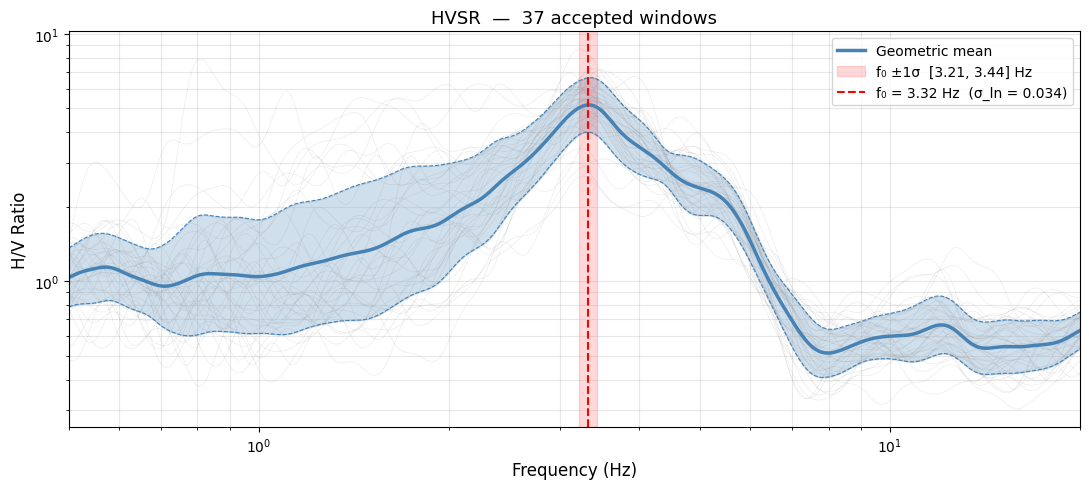

f0 (geometric mean) : 3.324 Hz
f0 ±1σ range        : [3.215, 3.438] Hz
σ_ln(f0)            : 0.0335
H/V at f0           : 5.16
Accepted windows    : 37


In [80]:
plot_hvsr(clean_hvsr_curves, fft_frq)